# **Task 1**

Tree A (depth=2):  Train: 0.94, Test: 0.98
Tree B (depth=10): Train: 1.00, Test: 1.00
Tree C (min=10):   Train: 0.94, Test: 0.98


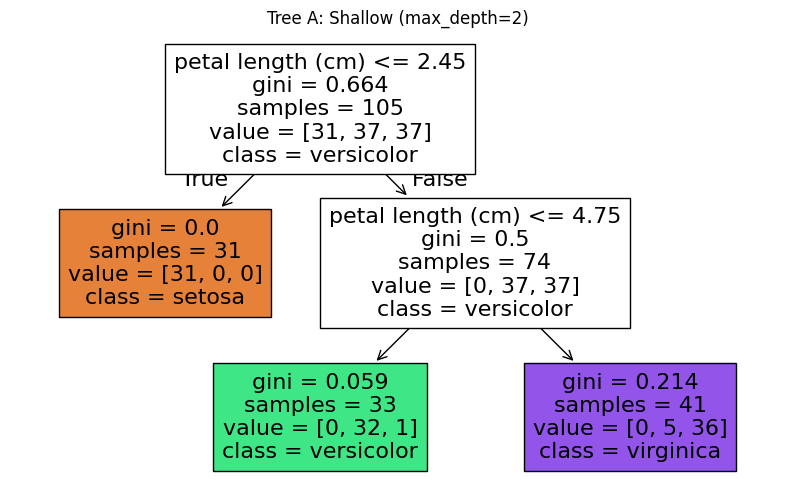

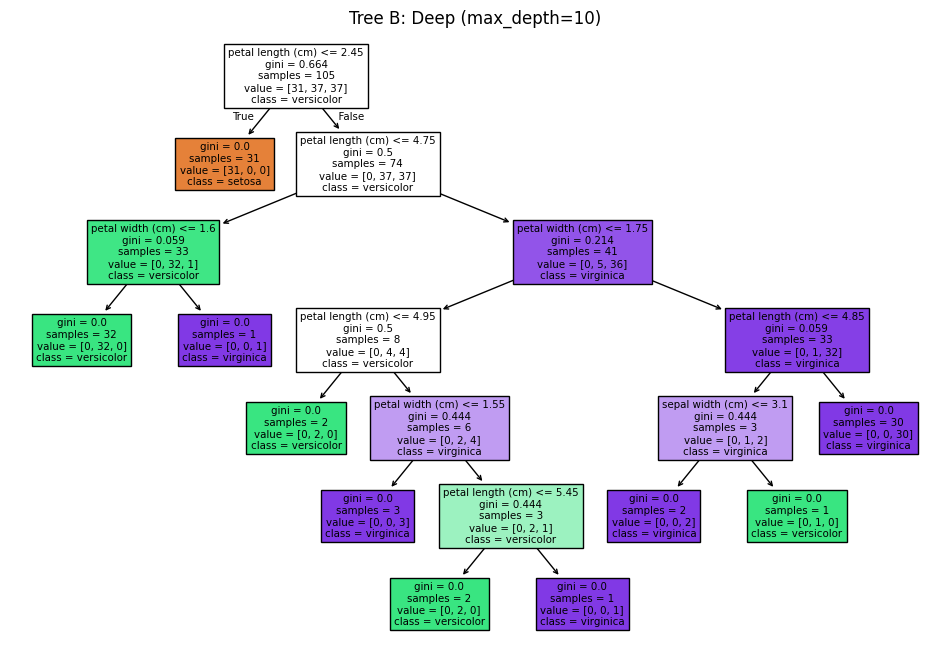

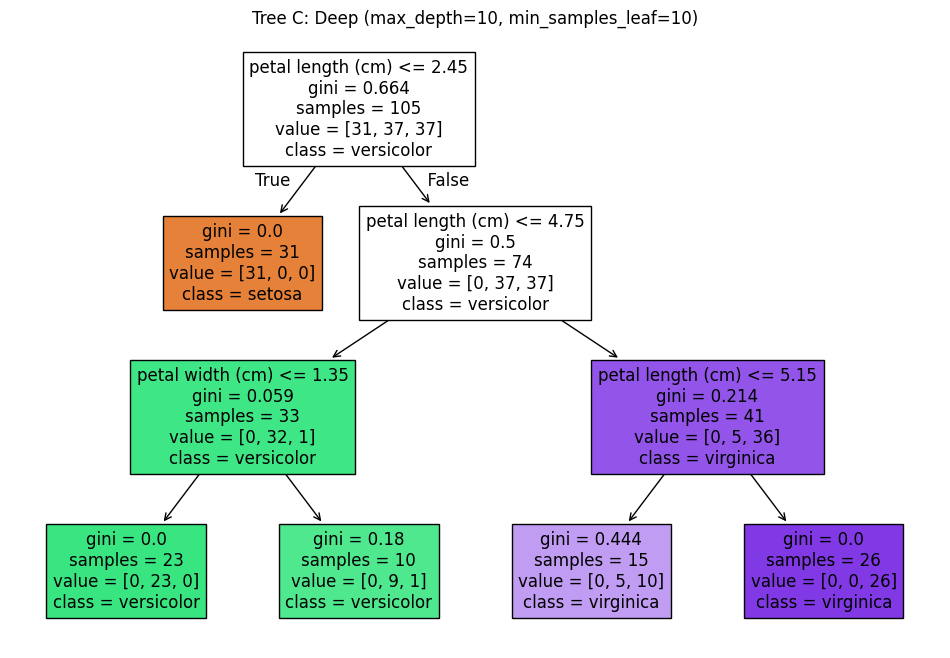

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load Data
iris = load_iris()
X, y = iris.data, iris.target

# 2. Split into Training (70%) and Testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Tree A: max_depth=2 ---
clf_a = DecisionTreeClassifier(max_depth=2, random_state=42)
clf_a.fit(X_train, y_train)
acc_train_a = accuracy_score(y_train, clf_a.predict(X_train))
acc_test_a = accuracy_score(y_test, clf_a.predict(X_test))

# --- Tree B: max_depth=10 ---
clf_b = DecisionTreeClassifier(max_depth=10, random_state=42)
clf_b.fit(X_train, y_train)
acc_train_b = accuracy_score(y_train, clf_b.predict(X_train))
acc_test_b = accuracy_score(y_test, clf_b.predict(X_test))

# --- Tree C: max_depth=10, min_samples_leaf=10 ---
clf_c = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, random_state=42)
clf_c.fit(X_train, y_train)
acc_train_c = accuracy_score(y_train, clf_c.predict(X_train))
acc_test_c = accuracy_score(y_test, clf_c.predict(X_test))

# 3. Report Accuracy
print(f"Tree A (depth=2):  Train: {acc_train_a:.2f}, Test: {acc_test_a:.2f}")
print(f"Tree B (depth=10): Train: {acc_train_b:.2f}, Test: {acc_test_b:.2f}")
print(f"Tree C (min=10):   Train: {acc_train_c:.2f}, Test: {acc_test_c:.2f}")

# 4. Visualize Tree A
plt.figure(figsize=(10, 6))
plot_tree(clf_a, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.title("Tree A: Shallow (max_depth=2)")
plt.show()

# 5. Visualize Tree B
plt.figure(figsize=(12, 8))
plot_tree(clf_b, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.title("Tree B: Deep (max_depth=10)")
plt.show()

# 6. Visualize Tree C
plt.figure(figsize=(12, 8))
plot_tree(clf_c, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.title("Tree C: Deep (max_depth=10, min_samples_leaf=10)")
plt.show()

# **Task 2**

In [3]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the dataset (Breast Cancer instead of Iris)
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# 2. Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model A: Unscaled Data ---
# Using a higher max_iter because unscaled data takes much longer to converge
model_a = LogisticRegression(max_iter=3000, random_state=42)
model_a.fit(X_train, y_train)
y_pred_a = model_a.predict(X_test)

# --- Model B: Scaled Data ---
# Scale the features so all measurements are on the same playing field
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_b = LogisticRegression(max_iter=3000, random_state=42)
model_b.fit(X_train_scaled, y_train)
y_pred_b = model_b.predict(X_test_scaled)

# 3. Performance Analysis
print("--- Accuracy Comparison ---")
print(f"Model A (Unscaled) Accuracy: {accuracy_score(y_test, y_pred_a):.4f}")
print(f"Model B (Scaled) Accuracy:   {accuracy_score(y_test, y_pred_b):.4f}\n")

# 4. The "Medical" Evaluation
# Target names help us see which row is Malignant (0) and Benign (1)
print("--- Classification Report (Scaled Model) ---")
print(classification_report(y_test, y_pred_b, target_names=cancer.target_names))

--- Accuracy Comparison ---
Model A (Unscaled) Accuracy: 0.9561
Model B (Scaled) Accuracy:   0.9737

--- Classification Report (Scaled Model) ---
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
